In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax
from flax import nnx
import orbax.checkpoint as ocp

from jaxpm import camels, data, plotting, graph
from jaxpm.painting import cic_paint, cic_read
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN

jax.devices("gpu")

[cuda(id=0)]

# functions

## training

In [3]:
@nnx.jit
def train_step(model, optimizer, x, y):

    def loss_fn(model):
        y_pred = model(*x, training=True)
        return jnp.mean((y - y_pred) **2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss

@nnx.jit
def vali_loop(model, X, Y):
    losses = []
    for i in range(scales.shape[0]):
        x, y = tuple(x[i] for x in X), Y[i]
        
        losses.append(jnp.mean((y - model(*x))**2))
    losses = jnp.mean(jnp.stack(losses))

    return losses
    
# NOTE this is GD, not SGD. There's no batches, all particles in the snapshot are evaluated every step
def train_model(
    model, 
    X,
    Y,
    X_vali,
    Y_vali,
    total_steps=3_000,
    vali_every=100,
    learning_rate=1e-3,
    cosine_decay=True,
):
    optimizer = optax.chain(
        optax.clip_by_global_norm(1),
        optax.adam(learning_rate)
    )
    optimizer = nnx.Optimizer(model, optimizer)

    if cosine_decay:
        learning_rate = optax.cosine_decay_schedule(
            init_value=learning_rate, 
            decay_steps=total_steps, 
            alpha=0.1
        )

    losses = []
    vali_steps = []
    vali_losses = []
    vali_loss = np.inf
    for i in (pbar := tqdm.tqdm(range(total_steps))):
        # select single snapshot
        j = np.random.choice(np.arange(scales.shape[0]))
        x, y = tuple(x[j] for x in X), Y[j]
        
        loss = train_step(model, optimizer, x, y)
        losses.append(loss)

        if (i % vali_every == 0) and (i != 0) or i == total_steps - 1:
            vali_steps.append(i)
            vali_loss = vali_loop(model, X_vali, Y_vali)
            vali_losses.append(vali_loss)

        pbar.set_description(f"train={loss:.4f}, vali={vali_loss:.4f}")

    fig, ax = plt.subplots()
    ax.plot(losses, label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend(loc="upper right")
    ax.set(yscale="log")
    

## plotting

In [4]:
def plot_preds(pred, label, pred_vali, label_vali):
    nrows = pred_vali.shape[0]
    ncols = 2
    
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))

    # fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))
    # ncols = y_true.shape[-1]

    for i in range(nrows):
        ax[i,0].scatter(label[i], pred[i], s=0.1, color="tab:blue")
    
        ax[i,0].plot([label[i].min(), label[i].max()], [label[i].min(), label[i].max()], color="k", linestyle="--")
        ax[i,0].set_aspect("equal")
        ax[i,0].set_box_aspect(1)
        # ax[i].set_yticks(ax[i].get_xticks())

    ax[0,0].set(title="training")
    
    for i in range(nrows):
        ax[i,1].scatter(label_vali[i], pred_vali[i], s=0.1, color="tab:orange")
    
        ax[i,1].plot([label_vali[i].min(), label_vali[i].max()], [label_vali[i].min(), label_vali[i].max()], color="k", linestyle="--")
        ax[i,1].set_aspect("equal")
        ax[i,1].set_box_aspect(1)
        # ax[i].set_yticks(ax[i].get_xticks())
    
    ax[0,1].set(title="validation")

    fig.tight_layout()

In [5]:
def normalized_paint(positions, weights):
    N_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_N = cic_read(N_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_N)


def plot_field(field, ax, vlims=None):
    log_sum = jnp.log10(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims
    
    return ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax), vlims, log_sum


def plot_comparison(true_field, pred_field, true_label="CAMELS", pred_label="", quantity_label="P", suptitle=""):
    fig, ax = plt.subplots(figsize=(3*6, 6+1), ncols=3)
    
    im, vlims, true_field_log_sum = plot_field(true_field, ax[0])
    ax[0].set(title=true_label)
    
    im, _, pred_field_log_sum = plot_field(pred_field, ax[1], vlims=vlims)
    ax[1].set(title=pred_label)
    
    fig.colorbar(im, ax=ax[:2], label=f"log(sum({quantity_label}))", orientation="horizontal", shrink=0.6, aspect=20)
    
    residual = true_field_log_sum - pred_field_log_sum
    lim = np.max(np.abs(residual[np.isfinite(residual)]))
    print(lim)
    im = ax[2].imshow(residual, cmap="seismic", vmin=-lim, vmax=lim)
    ax[2].set(title="residual (true - pred)")
    fig.colorbar(im, ax=ax[2], label=f"log(sum({quantity_label}_1)) - log(sum({quantity_label}_2))", orientation="horizontal", shrink=0.6, aspect=10)
    
    for i in range(len(ax)):
        ax[i].set_yticks([])
        ax[i].set_xticks([])
    
    fig.suptitle(suptitle, fontsize=16)

In [6]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## CAMELS snapshots

In [7]:
i_snapshots = [-2, -1]
# i_snapshots = [0, -1]
# i_snapshots = range(1, 33+4, 4)
# i_snapshots = None

In [8]:
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0"
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0"

train_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Loaded /cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-2, -1].h5


In [9]:
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1"
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1"

test_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Loaded /cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/parts=64,mesh=64,i=[-2, -1].h5


# Preprocessing

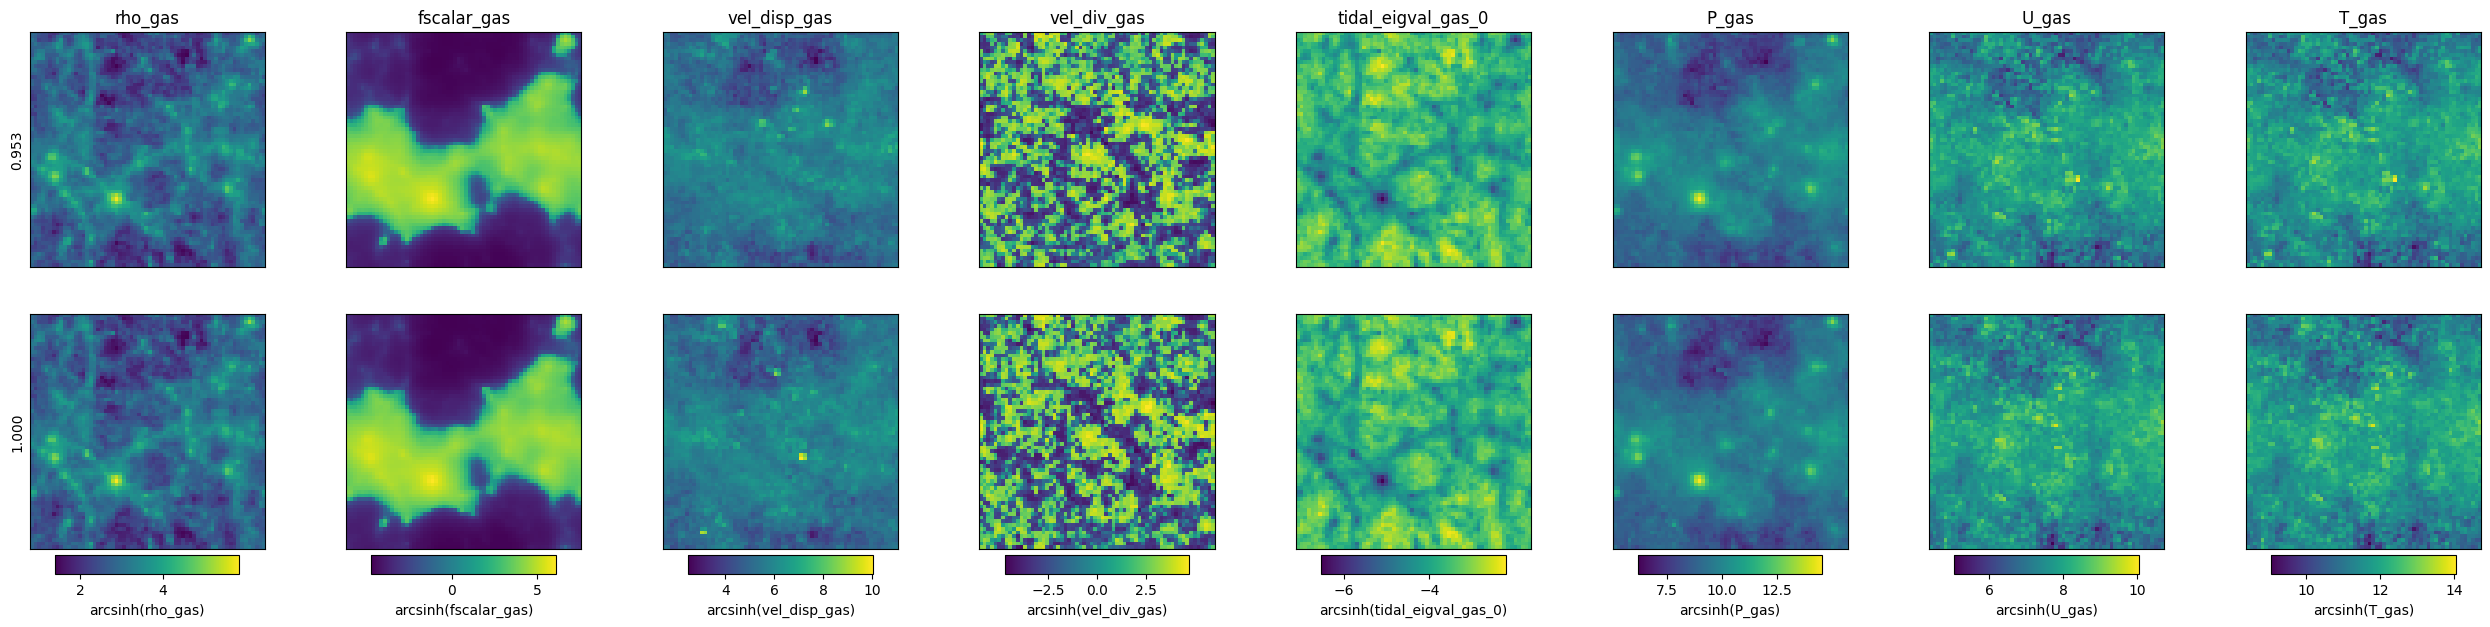

In [10]:
scales, particle_features, field_features = camels.preprocess_snapshots(train_dict)
plotting.plot_gas_features(scales, field_features)

# Network selection

In [11]:
def train_mlp(x_labels, y_labels):
    X, _, Y, _ = data.get_offline_regression_data(train_dict, x_labels=x_labels, y_labels=y_labels, standardize_input=False)
    X_vali, _, Y_vali, _ = data.get_offline_regression_data(test_dict, x_labels=x_labels, y_labels=y_labels, standardize_input=False)

    model = MLP(
        X.shape[-1], 
        Y.shape[-1], 
        128, 
        4,
        nnx.Rngs(0),
        0.0,
    )
    
    train_model(
        model,
        (X,),
        Y,
        (X_vali,),
        Y_vali,
    )

    pred = model(X)
    pred_vali = model(X_vali)
    
    plot_preds(pred, Y, pred_vali, Y_vali)
    
    i = -1
    P_pred = normalized_paint(test_dict["gas_poss"][i], jnp.squeeze(10**pred_vali[i]) + 1)
    P_camels = normalized_paint(test_dict["gas_poss"][i], test_dict["gas_Ps"][i])
    
    plot_comparison(P_camels, P_pred, pred_label="MLP", suptitle="validation set")
    
    return model

# def train_hybrid(x_labels, y_labels):
#     X_particle, X_field, Y = get_data(train_dict, y_labels=y_labels)
#     X_particle_vali, X_field_vali, Y_vali = get_data(test_dict, y_labels=y_labels)
    
#     mlp = MLP(
#         d_in=X_particle.shape[-1], 
#         d_out=8, 
#         d_hidden=64, 
#         n_hidden=4, 
#         rngs=nnx.Rngs(0)
#     )
    
#     cnn = CNN(
#         d_in=X_field.shape[-1], 
#         d_out=8,
#         d_hidden=16,
#         n_hidden=1,
#         kernel_size=(3, 3, 3),
#         strides=1,
#         rngs=nnx.Rngs(0)
#     )
    
#     hybrid = HybridNet(
#         mlp,
#         cnn,
#         d_out=Y.shape[-1],
#         rngs=nnx.Rngs(0),
#         batch_axis=False,
#     )    
    # return hybrid


def train_gnn(x_labels, y_labels):
    X, Y = graph.get_graphs_from_snapshots(
        train_dict,
        x_labels=x_labels,
        y_labels=y_labels,
        k=16, 
        # boxsize=mesh_per_dim
    )
    
    X_vali, Y_vali = graph.get_graphs_from_snapshots(
        test_dict,
        x_labels=x_labels,
        y_labels=y_labels,
        k=16, 
        # boxsize=mesh_per_dim
    )

    model = AttentionGNN(
        d_node=X[0].nodes.shape[-1],
        d_edge=X[0].edges.shape[-1],
        d_query=16,
        n_hidden=4,
        d_out=Y.shape[-1],
        rngs=nnx.Rngs(0),
    )
    
    train_model(
        model,
        (X,),
        Y,
        (X_vali,),
        Y_vali,
    )

    pred = []
    for x in X:
        pred.append(model(x))
    pred = jnp.stack(pred, axis=0)
        
    pred_vali = []
    for x in X_vali:
        pred_vali.append(model(x))
    pred_vali = jnp.stack(pred_vali, axis=0)

    plot_preds(pred, Y, pred_vali, Y_vali)

    i = -1
    P_pred = normalized_paint(test_dict["gas_poss"][i], jnp.squeeze(10**pred_vali[i]) - 1)
    P_camels = normalized_paint(test_dict["gas_poss"][i], test_dict["gas_Ps"][i])
    plot_comparison(P_camels, P_pred, pred_label="GNN", suptitle="validation set")
    
    return model


In [12]:
# x_labels = ["rho"]
# y_labels = ["P"]

# # model = train_mlp(x_labels, y_labels)
# model = train_gnn(x_labels, y_labels)

In [23]:
# x_labels = ["fscalar"]
# y_labels = ["P"]

# model = train_mlp(x_labels, y_labels)
# # model = train_gnn(x_labels, y_labels)

In [24]:
# x_labels = ["rho", "fscalar"]
# y_labels = ["P"]

# # model = train_mlp(x_labels, y_labels)
# model = train_gnn(x_labels, y_labels)

train=0.2569, vali=0.3024: 100%|██████████| 3000/3000 [03:00<00:00, 16.59it/s]


0.963707


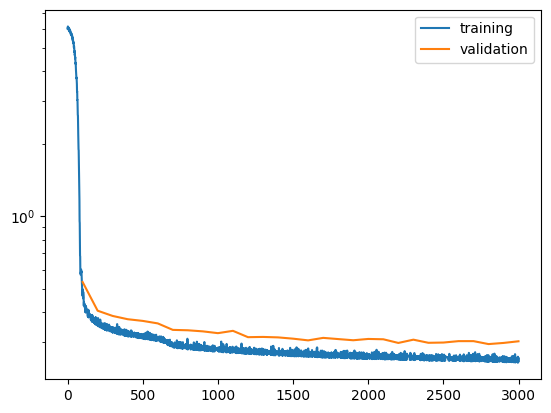

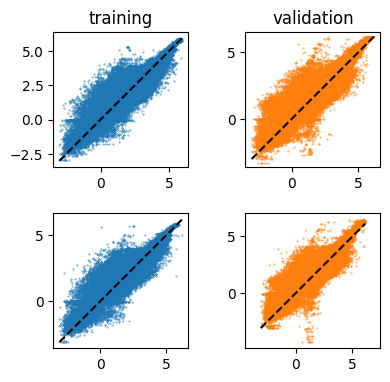

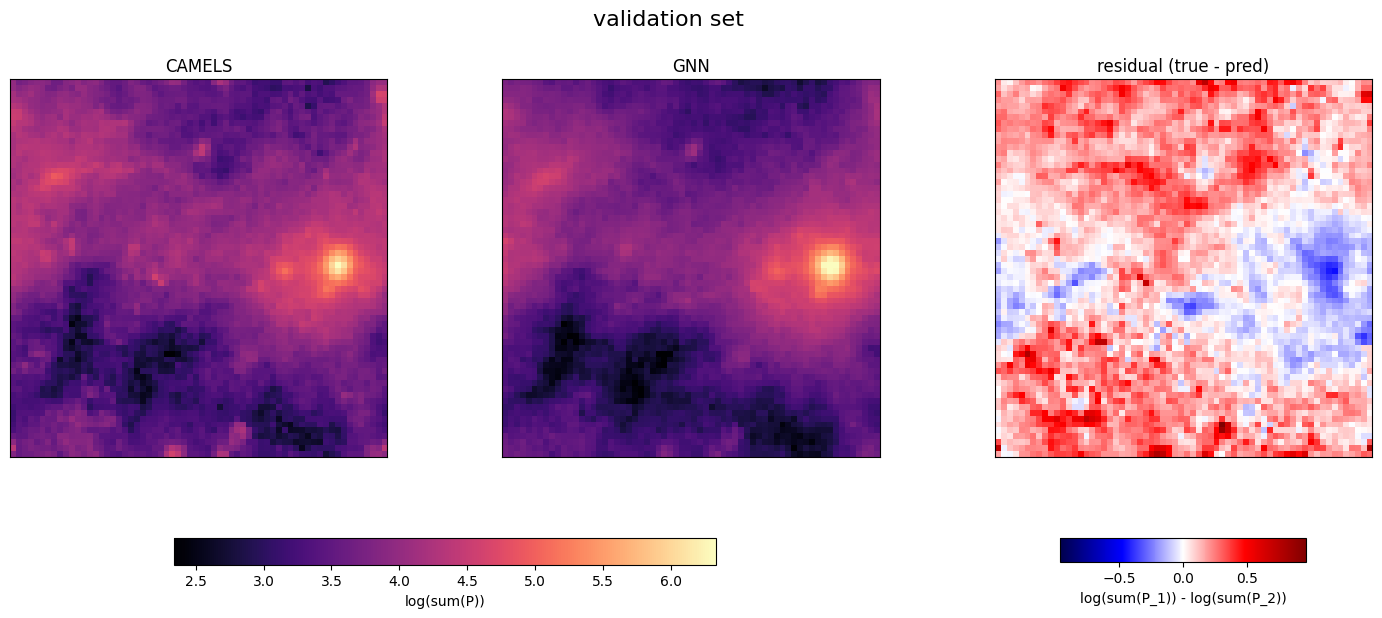

In [18]:
x_labels = ["rho", "fscalar", "vel_disp", "vel_div"]
y_labels = ["P"]

# model = train_mlp(x_labels, y_labels)
model = train_gnn(x_labels, y_labels)

train=0.2518, vali=0.3094: 100%|██████████| 3000/3000 [02:58<00:00, 16.82it/s]


1.1068473


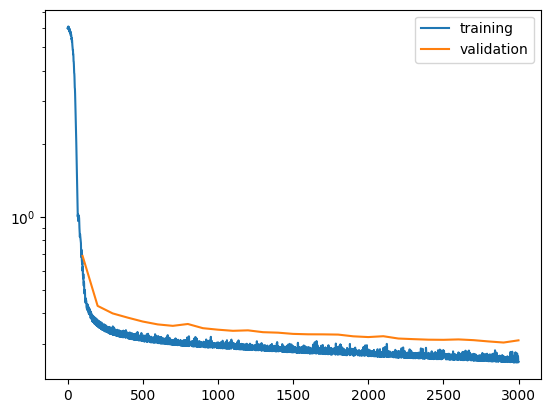

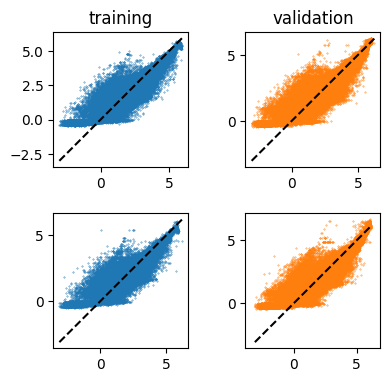

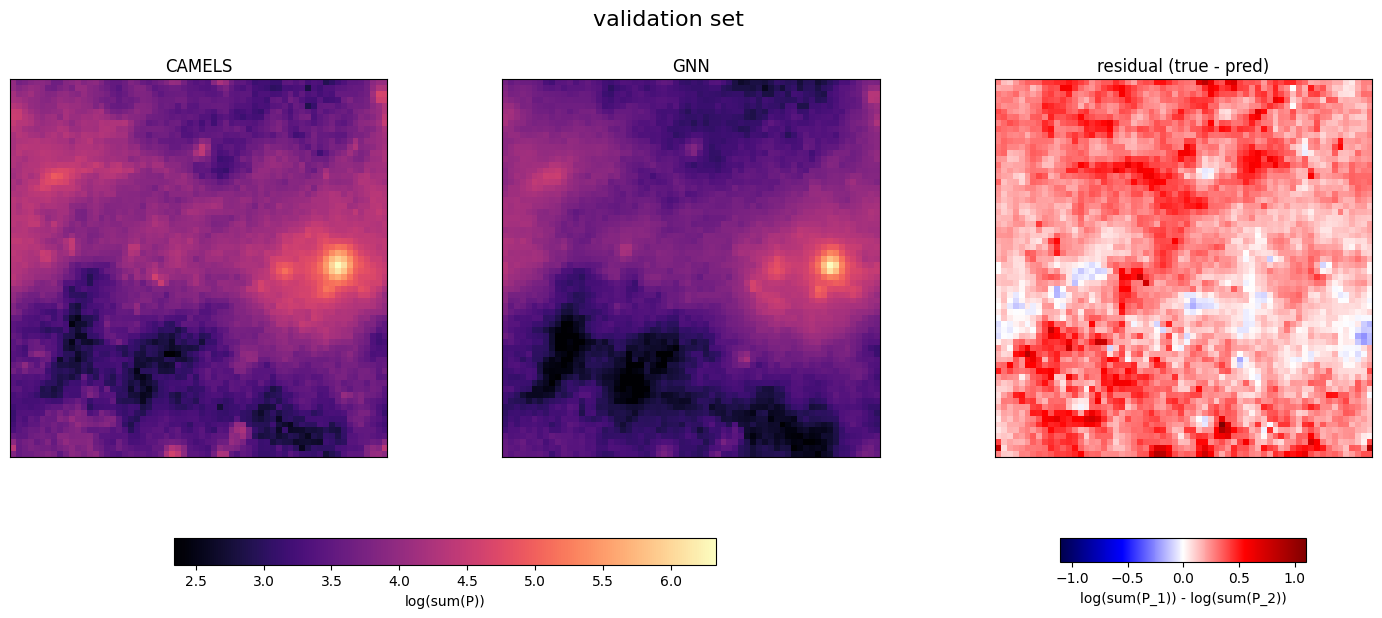

In [19]:
x_labels = ["rho", "fscalar", "vel_disp", "vel_div", "tidal_eigval_0", "tidal_eigval_1", "tidal_eigval_2"]
y_labels = ["P"]

# model = train_mlp(x_labels, y_labels)
model = train_gnn(x_labels, y_labels)

# trash

train=0.2501, vali=41.2874: 100%|██████████| 3000/3000 [00:53<00:00, 55.97it/s]


10.362287


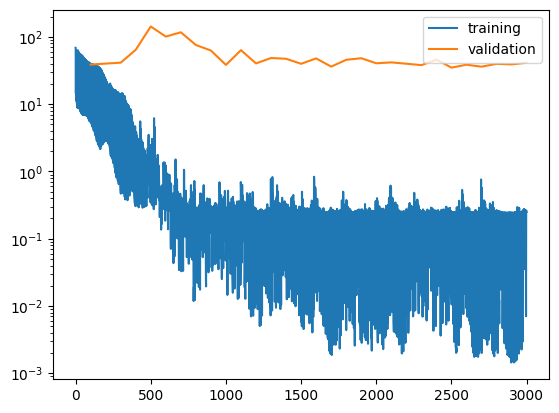

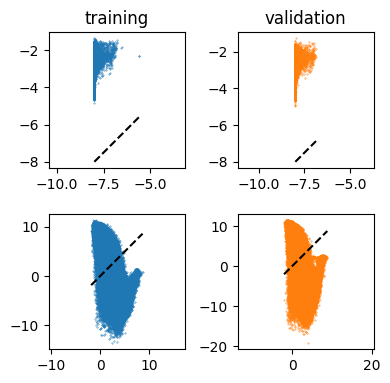

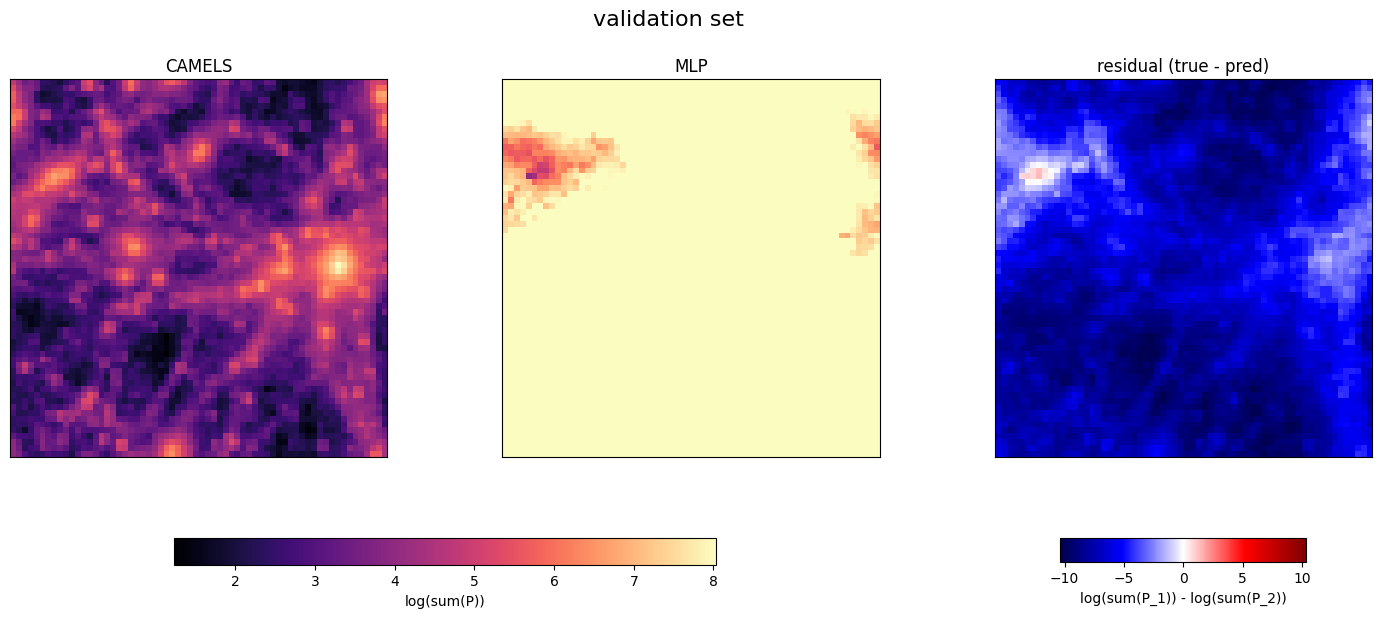

In [16]:
# x_labels = ["rho", "fscalar", "vel_disp", "vel_div"]
x_labels = ["rho", "fscalar"]
y_labels = ["P"]

model = train_mlp(x_labels, y_labels)
# model = train_gnn(x_labels, y_labels)

In [21]:
train_dict["scales"]**5

array([9.56907452e-07, 1.00000000e+00])

In [17]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_table_v1.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [18]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [19]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)